#### 1. Import the Relevent Packages

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from glob import glob
from torchsummary import summary
import os
import warnings
warnings.filterwarnings('ignore')

In [17]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### 2. Prepare the Dataset

In [18]:
class MyDataset(Dataset):
    
    def __init__(self, root, transform_status=True):
        
        self.root = root
        self.images_paths = [glob(f'{root}/{folder}/*.jpg') for folder in os.listdir(f"{root}")] 

        import itertools
        self.images_paths = list(itertools.chain.from_iterable(self.images_paths))

        import random
        random.shuffle(self.images_paths)

        self.classes_names = {class_name:label for label, class_name in enumerate(os.listdir(f"{root}"))}
        self.labels = [self.classes_names[os.path.basename(os.path.dirname(path))] for path in self.images_paths]
        self.transform_status = transform_status
        self.transform = transforms.Normalize(mean=[0.485,0.456, 0.406],std=[0.229, 0.224, 0.225])
    
    def __len__(self):
        return len(self.images_paths)   
        
    def __getitem__(self, index):
        image_path = self.images_paths[index]
        image = cv2.imread(image_path)[:,:,::-1]
        image = cv2.resize(image, (64,64))
        image = torch.tensor(image/255).permute(2,0,1)
        if self.transform_status: image = self.transform(image)
        label = self.labels[index]
        
        # FIXED LINE BELOW: Removed brackets around label and changed .float() to .long()
        return image.float().to(device), torch.tensor(label).long().to(device)

In [19]:
data =  MyDataset("dataset_rgb/train", transform_status=False)

In [20]:
data.classes_names

{'AnnualCrop': 0,
 'Forest': 1,
 'HerbaceousVegetation': 2,
 'Highway': 3,
 'Industrial': 4,
 'Pasture': 5,
 'PermanentCrop': 6,
 'Residential': 7,
 'River': 8,
 'SeaLake': 9}

In [21]:
import random
image, label = data[random.randint(0, len(data))]

Image Size: 64 x 64 x 3
Label: 2
HerbaceousVegetation


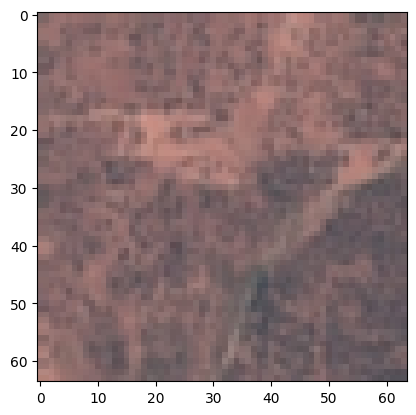

In [22]:
print(f"Image Size: {image.shape[2]} x {image.shape[1]} x {image.shape[0]}")
print(f"Label: {label}")
print([key  for key, value in data.classes_names.items() if value == label][0])
plt.imshow(image.permute(1,2,0).cpu().numpy())
plt.show()

In [23]:
train_dataset = MyDataset("dataset_rgb/train", transform_status=True)
test_dataset = MyDataset("dataset_rgb/test", transform_status=True)
train_dataset_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_dataset_loader = DataLoader(test_dataset, batch_size=32, shuffle=True, drop_last=True)

#### 3. Build the Model

In [24]:
def conv_block(in_channels, out_channels, kernel_size=3, stride=1, padding=1):
    return nn.Sequential(
        nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=1)
    )
def build_model():
    model = nn.Sequential(
        conv_block(3, 64,3),
        conv_block(64, 128,3),
        conv_block(128, 256,3),
        conv_block(256, 512,3),
        nn.AdaptiveAvgPool2d((1,1)),
        nn.Flatten(),
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64, 10),
    )
        

    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    return model.to(device) , loss_fn, optimizer


In [25]:
model , loss_function, optimizer = build_model()

In [26]:
summary(model, (3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 64, 64]           1,792
       BatchNorm2d-2           [-1, 64, 64, 64]             128
              ReLU-3           [-1, 64, 64, 64]               0
         MaxPool2d-4           [-1, 64, 63, 63]               0
            Conv2d-5          [-1, 128, 63, 63]          73,856
       BatchNorm2d-6          [-1, 128, 63, 63]             256
              ReLU-7          [-1, 128, 63, 63]               0
         MaxPool2d-8          [-1, 128, 62, 62]               0
            Conv2d-9          [-1, 256, 62, 62]         295,168
      BatchNorm2d-10          [-1, 256, 62, 62]             512
             ReLU-11          [-1, 256, 62, 62]               0
        MaxPool2d-12          [-1, 256, 61, 61]               0
           Conv2d-13          [-1, 512, 61, 61]       1,180,160
      BatchNorm2d-14          [-1, 512,

#### 4. Build the Train and Accuracy Functions 

In [27]:
def train_batch(model, loss_function, optimizer, image, label):
    model.train()
    optimizer.zero_grad()
    prediction = model(image)
    loss = loss_function(prediction, label.long().squeeze())
    loss.backward()
    optimizer.step()
    return loss.item()

In [28]:
@torch.no_grad()
def accuracy(model, loss_function, image, label):
    model.eval()
    prediction = model(image)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == label.long().squeeze()
    return is_correct.cpu().numpy().tolist()

In [29]:
@torch.no_grad()
def validation_loss(model, loss_function, image, label):
    model.eval()
    prediction = model(image)
    loss = loss_function(prediction, label.long().squeeze())
    return loss.item()

In [30]:
import torch
import numpy as np

# 1. Setup Device (CRITICAL for speed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Move model to GPU if available
model = model.to(device)

train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

for epoch in range(25):
    print(f"--- Epoch: {epoch+1}/25 ---")
    
    # ==========================
    # TRAINING PHASE
    # ==========================
    model.train() # Put model in training mode
    train_epoch_losses = []
    correct_train = 0
    total_train = 0
    
    # Just ONE loop for training and accuracy
    for images, labels in train_dataset_loader:
        # Move data to GPU
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Track Loss
        train_epoch_losses.append(loss.item())
        
        # Track Accuracy (calculate right here using the outputs we just generated!)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_epoch_loss = np.mean(train_epoch_losses)
    train_epoch_accuracy = correct_train / total_train
    
    print(f"Train Loss: {train_epoch_loss:.4f} | Train Accuracy: {train_epoch_accuracy*100:.2f}%")
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    
    # ==========================
    # VALIDATION PHASE
    # ==========================
    model.eval() # Put model in evaluation mode (turns off Dropout/BatchNorm updates)
    test_epoch_losses = []
    correct_test = 0
    total_test = 0
    
    # Use torch.no_grad() to save memory and speed up validation
    with torch.no_grad():
        for images, labels in test_dataset_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = loss_function(outputs, labels)
            test_epoch_losses.append(loss.item())
            
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    test_epoch_loss = np.mean(test_epoch_losses)
    test_epoch_accuracy = correct_test / total_test
    
    print(f"Test Loss: {test_epoch_loss:.4f} | Test Accuracy: {test_epoch_accuracy*100:.2f}%")
    test_losses.append(test_epoch_loss)
    test_accuracies.append(test_epoch_accuracy)

Training on device: cuda
--- Epoch: 1/25 ---
Train Loss: 1.0316 | Train Accuracy: 63.98%
Test Loss: 0.7130 | Test Accuracy: 72.64%
--- Epoch: 2/25 ---
Train Loss: 0.7472 | Train Accuracy: 74.10%
Test Loss: 1.5095 | Test Accuracy: 63.02%
--- Epoch: 3/25 ---
Train Loss: 0.6720 | Train Accuracy: 76.96%
Test Loss: 0.7217 | Test Accuracy: 74.80%
--- Epoch: 4/25 ---
Train Loss: 0.6003 | Train Accuracy: 80.08%
Test Loss: 0.5973 | Test Accuracy: 78.83%
--- Epoch: 5/25 ---
Train Loss: 0.5594 | Train Accuracy: 81.34%
Test Loss: 0.4492 | Test Accuracy: 84.17%
--- Epoch: 6/25 ---
Train Loss: 0.5089 | Train Accuracy: 83.38%
Test Loss: 0.5050 | Test Accuracy: 82.75%
--- Epoch: 7/25 ---
Train Loss: 0.4695 | Train Accuracy: 84.73%
Test Loss: 0.7165 | Test Accuracy: 74.38%
--- Epoch: 8/25 ---
Train Loss: 0.4378 | Train Accuracy: 86.00%
Test Loss: 0.5224 | Test Accuracy: 82.29%
--- Epoch: 9/25 ---
Train Loss: 0.3963 | Train Accuracy: 87.32%
Test Loss: 0.7964 | Test Accuracy: 79.25%
--- Epoch: 10/25 ---


#### 6. Visualize the Train Loss/Accuracy and the Test Loss/Accuracy

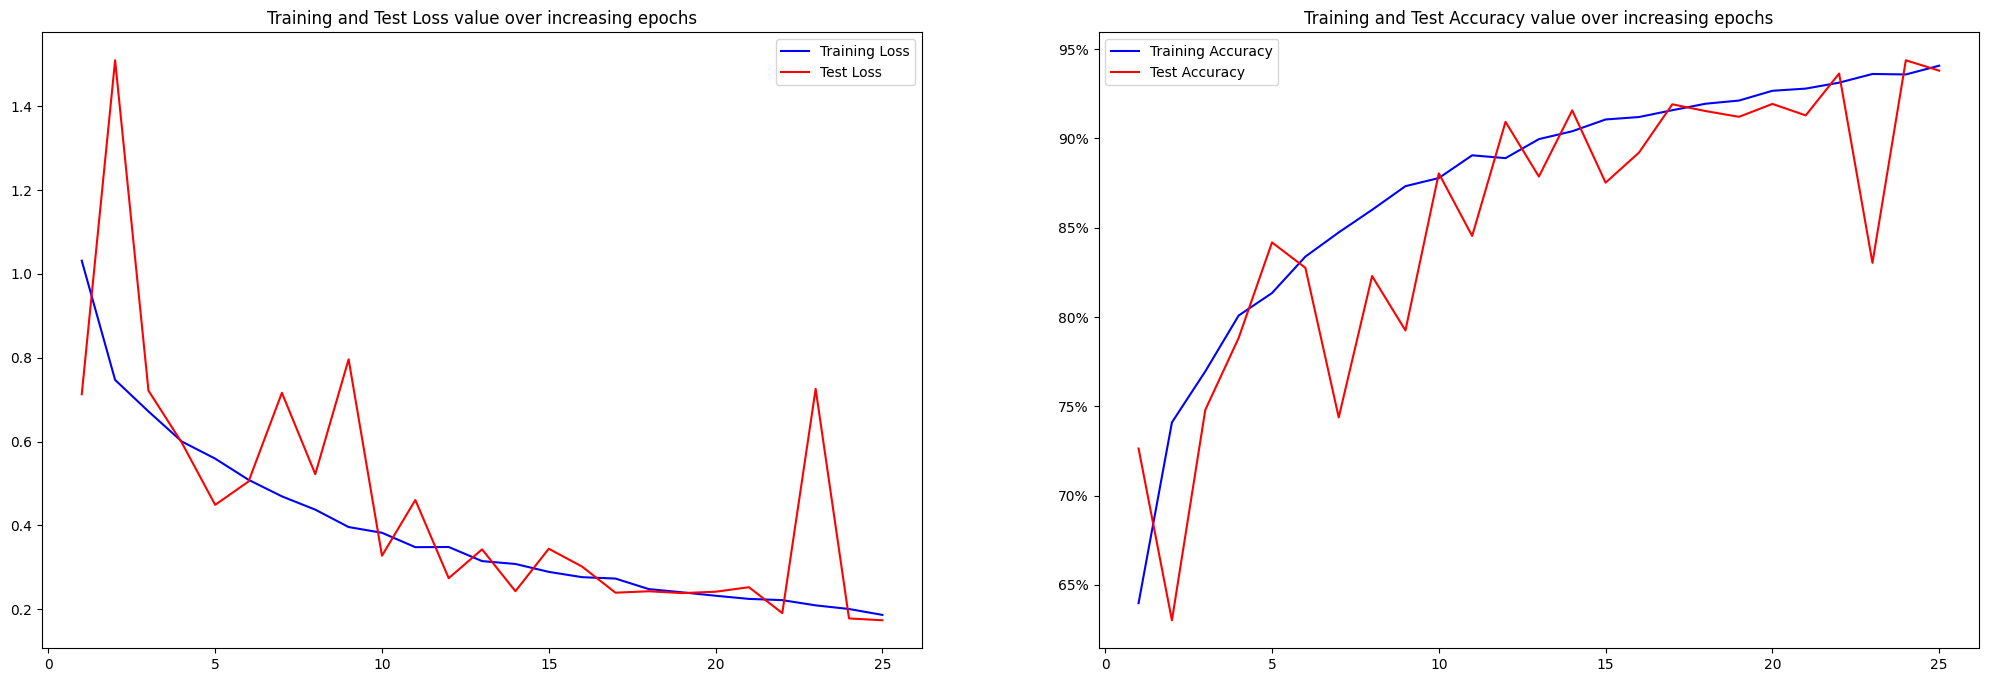

In [31]:
epochs = np.arange(25)+1
plt.figure(figsize=(25,8))
plt.subplot(121)
plt.title('Training and Test Loss value over increasing epochs')
plt.plot(epochs, train_losses,'b', label='Training Loss')
plt.plot(epochs, test_losses,'r', label='Test Loss')
plt.legend()
plt.subplot(122)
plt.title('Training and Test Accuracy value over increasing epochs')
plt.plot(epochs, train_accuracies,'b', label='Training Accuracy')
plt.plot(epochs, test_accuracies,'r', label='Test Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.show()